# 🛒 Product Review Sentiment Analysis using Deep Learning

**Objective:** Build a deep learning model to classify Amazon product reviews as **Positive** or **Negative**.

**Key Challenge:** The dataset is **highly imbalanced** — there are far more positive reviews than negative ones.

**Approach:**
- Proper EDA with rich visualizations
- Text preprocessing & tokenization
- SMOTE-like oversampling of minority class + class weights
- Bidirectional LSTM with tuned architecture
- Comprehensive evaluation with confusion matrix, ROC curve, and per-class analysis

In [16]:
# ========== IMPORTS ==========
import os, re, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc, precision_recall_curve)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, LSTM, Dense, Bidirectional,
                                     Dropout, SpatialDropout1D, GlobalMaxPooling1D,
                                     BatchNormalization, Conv1D, MaxPooling1D)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.20.0


---
## 📊 1. Data Loading & Exploration

In [17]:
df = pd.read_csv('../datasets/amazon.csv')
print(f'Dataset shape: {df.shape}')
print(f'\nColumns: {list(df.columns)}')
df.head()

Dataset shape: (4915, 12)

Columns: ['Unnamed: 0', 'reviewerName', 'overall', 'reviewText', 'reviewTime', 'day_diff', 'helpful_yes', 'helpful_no', 'total_vote', 'score_pos_neg_diff', 'score_average_rating', 'wilson_lower_bound']


,Unnamed: 0,reviewerName,overall,reviewText,reviewTime,day_diff,helpful_yes,helpful_no,total_vote,score_pos_neg_diff,score_average_rating,wilson_lower_bound
0,0,NaN,4,No issues.,23-07-2014,138,0,0,0,0,0.0,0.0
1,1,0mie,5,"Purchased this for my device, it worked as adv...",25-10-2013,409,0,0,0,0,0.0,0.0
2,2,1K3,4,it works as expected. I should have sprung for...,23-12-2012,715,0,0,0,0,0.0,0.0
3,3,1m2,5,This think has worked out great.Had a diff. br...,21-11-2013,382,0,0,0,0,0.0,0.0
4,4,2&amp;1/2Men,5,"Bought it with Retail Packaging, arrived legit...",13-07-2013,513,0,0,0,0,0.0,0.0


In [18]:
print('Missing values:')
print(df.isnull().sum())
print(f'\nTotal duplicate rows: {df.duplicated().sum()}')
print(f'\nRating distribution:\n{df["overall"].value_counts().sort_index()}')

Missing values:
Unnamed: 0              0
reviewerName            1
overall                 0
reviewText              1
reviewTime              0
day_diff                0
helpful_yes             0
helpful_no              0
total_vote              0
score_pos_neg_diff      0
score_average_rating    0
wilson_lower_bound      0
dtype: int64

Total duplicate rows: 0

Rating distribution:
overall
1     244
2      80
3     142
4     527
5    3922
Name: count, dtype: int64


### 📈 EDA Chart 1: Rating Distribution

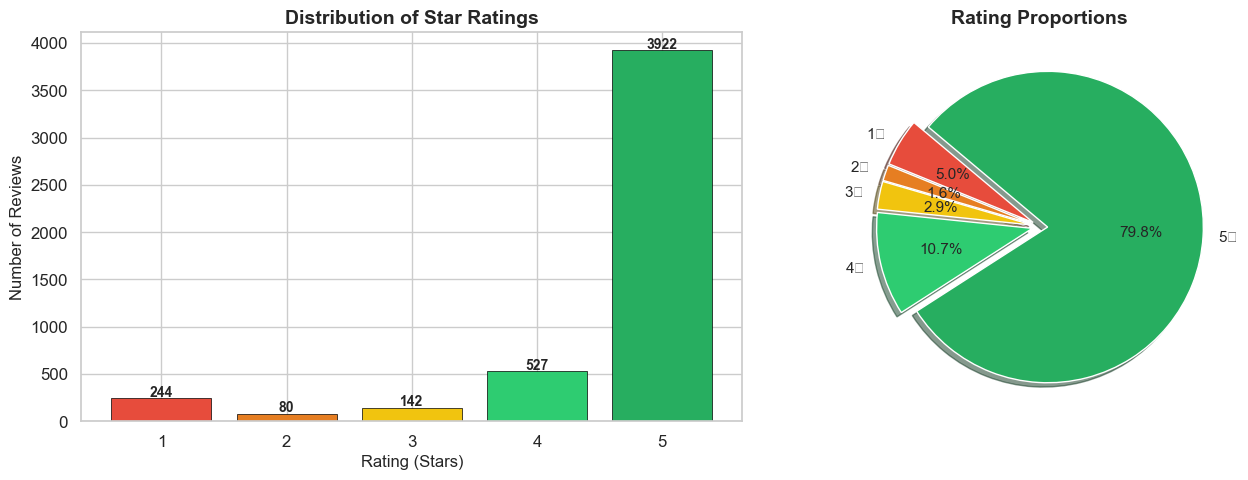

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']
rating_counts = df['overall'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_xlabel('Rating (Stars)', fontsize=12)
axes[0].set_ylabel('Number of Reviews', fontsize=12)
axes[0].set_title('Distribution of Star Ratings', fontsize=14, fontweight='bold')
for i, (idx, val) in enumerate(zip(rating_counts.index, rating_counts.values)):
    axes[0].text(idx, val + 20, str(val), ha='center', fontweight='bold', fontsize=10)

# Pie chart
axes[1].pie(rating_counts.values, labels=[f'{i}⭐' for i in rating_counts.index],
            autopct='%1.1f%%', colors=colors, startangle=140,
            explode=[0.05]*len(rating_counts), shadow=True, textprops={'fontsize': 11})
axes[1].set_title('Rating Proportions', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../models/eda_rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 🏷️ Sentiment Labeling
Map ratings to binary sentiment: **Positive** (4-5) vs **Negative** (1-2). Remove neutral (3) reviews.

In [20]:
df = df.dropna(subset=['reviewText', 'overall'])
df = df[df['overall'] != 3].copy()
df['sentiment'] = df['overall'].apply(lambda x: 1 if x > 3 else 0)
df['sentiment_label'] = df['sentiment'].map({0: 'Negative', 1: 'Positive'})

print(f'After filtering: {len(df)} reviews')
print(f'\nSentiment distribution:\n{df["sentiment"].value_counts()}')
print(f'\nImbalance ratio: {df["sentiment"].value_counts()[1] / df["sentiment"].value_counts()[0]:.1f}x more positive')

After filtering: 4772 reviews

Sentiment distribution:
sentiment
1    4448
0     324
Name: count, dtype: int64

Imbalance ratio: 13.7x more positive


### 📈 EDA Chart 2: Sentiment Class Imbalance

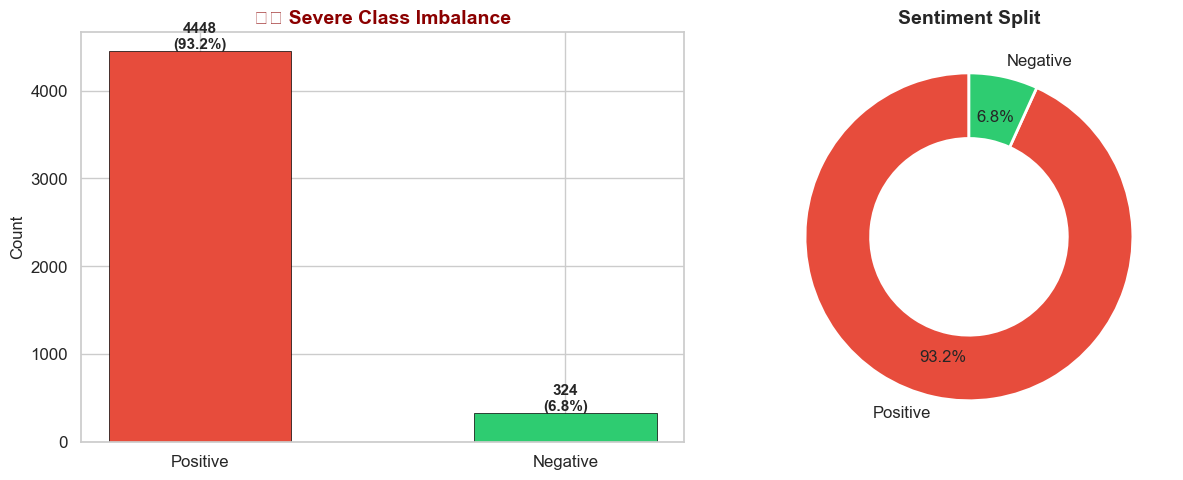

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sent_counts = df['sentiment_label'].value_counts()
bar_colors = ['#e74c3c', '#2ecc71']

# Bar chart
bars = axes[0].bar(sent_counts.index, sent_counts.values, color=bar_colors,
                   edgecolor='black', linewidth=0.5, width=0.5)
for bar, val in zip(bars, sent_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('⚠️ Severe Class Imbalance', fontsize=14, fontweight='bold', color='darkred')

# Donut chart
wedges, texts, autotexts = axes[1].pie(sent_counts.values, labels=sent_counts.index,
    autopct='%1.1f%%', colors=bar_colors, startangle=90, pctdistance=0.75,
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2), textprops={'fontsize':12})
axes[1].set_title('Sentiment Split', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../models/eda_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

### 📈 EDA Chart 3: Review Length Analysis

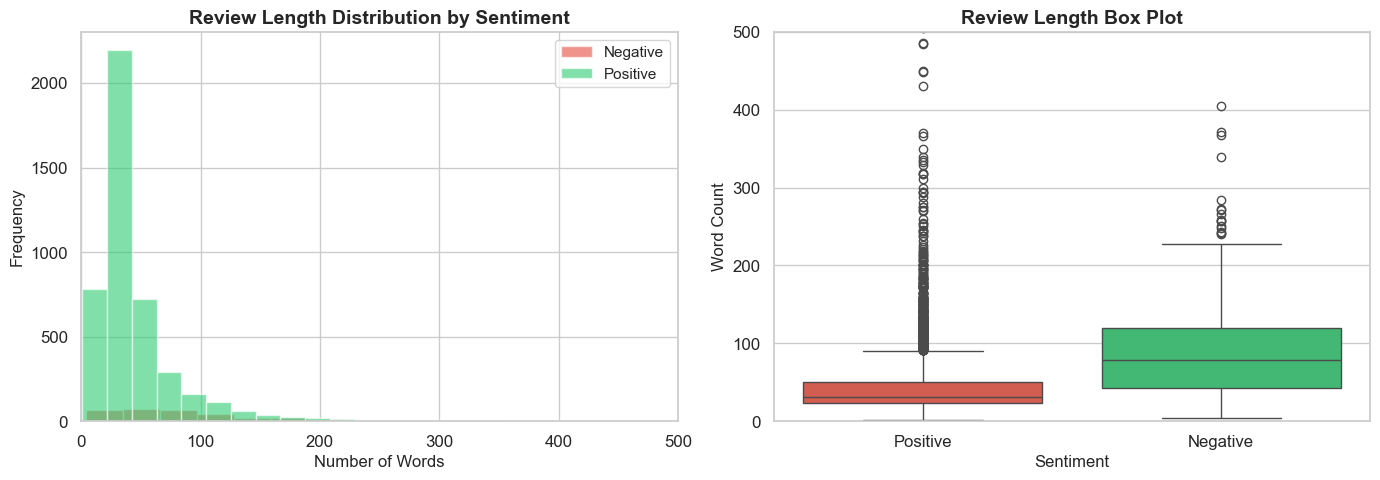

Average review length:
                       mean   50%     max
sentiment_label                          
Negative         106.478395  78.0  1554.0
Positive          45.643660  31.0  1037.0


In [22]:
df['review_length'] = df['reviewText'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram by sentiment
for label, color in zip(['Negative', 'Positive'], ['#e74c3c', '#2ecc71']):
    subset = df[df['sentiment_label'] == label]['review_length']
    axes[0].hist(subset, bins=50, alpha=0.6, color=color, label=label, edgecolor='white')
axes[0].set_xlabel('Number of Words', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Review Length Distribution by Sentiment', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].set_xlim(0, 500)

# Box plot
sns.boxplot(data=df, x='sentiment_label', y='review_length', palette=['#e74c3c', '#2ecc71'], ax=axes[1])
axes[1].set_ylim(0, 500)
axes[1].set_title('Review Length Box Plot', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sentiment', fontsize=12)
axes[1].set_ylabel('Word Count', fontsize=12)

plt.tight_layout()
plt.savefig('../models/eda_review_lengths.png', dpi=150, bbox_inches='tight')
plt.show()

print('Average review length:')
print(df.groupby('sentiment_label')['review_length'].describe()[['mean', '50%', 'max']])

---
## 🧹 2. Text Preprocessing

In [23]:
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))
# Keep negation words — crucial for sentiment!
negation_words = {'not', 'no', 'nor', 'neither', 'never', 'none', 'nobody',
                  'nothing', 'nowhere', 'hardly', 'barely', 'scarcely',
                  "don't", "doesn't", "didn't", "won't", "wouldn't",
                  "can't", "couldn't", "shouldn't", "isn't", "aren't",
                  "wasn't", "weren't", "hasn't", "haven't", "hadn't"}
stop_words = stop_words - negation_words

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<[^>]+>', '', text)           # Remove HTML tags
    text = re.sub(r'http\S+|www\S+', '', text)    # Remove URLs
    text = re.sub(r'[^a-z\s]', '', text)          # Keep only letters
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words and len(w) > 1]
    return ' '.join(tokens)

df['clean_text'] = df['reviewText'].apply(clean_text)
print('Sample cleaned reviews:')
for i in range(3):
    print(f'  [{df.iloc[i]["sentiment_label"]}] {df.iloc[i]["clean_text"][:100]}...')

Sample cleaned reviews:
  [Positive] no issues...
  [Positive] purchased device worked advertised never much phone memory since download lot stuff no brainer...
  [Positive] works expected sprung higher capacity think made bit cheesier earlier versions paint looks not clean...


---
## ✂️ 3. Train-Test Split & Tokenization

In [24]:
X = df['clean_text'].values
y = df['sentiment'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {len(X_train)} | Test: {len(X_test)}')
print(f'Train class distribution: {Counter(y_train)}')
print(f'Test  class distribution: {Counter(y_test)}')

Train: 3817 | Test: 955
Train class distribution: Counter({np.int64(1): 3558, np.int64(0): 259})
Test  class distribution: Counter({np.int64(1): 890, np.int64(0): 65})


In [25]:
VOCAB_SIZE = 15000
MAX_LEN = 200
EMBEDDING_DIM = 128

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train),
                            maxlen=MAX_LEN, padding='post', truncating='post')
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test),
                           maxlen=MAX_LEN, padding='post', truncating='post')

print(f'Vocabulary size: {min(len(tokenizer.word_index)+1, VOCAB_SIZE)}')
print(f'Train shape: {X_train_seq.shape}')
print(f'Test  shape: {X_test_seq.shape}')

# Save tokenizer
with open('../trained_models/tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print('\n✅ Tokenizer saved to trained_models/tokenizer.pkl')

Vocabulary size: 8305
Train shape: (3817, 200)
Test  shape: (955, 200)

✅ Tokenizer saved to trained_models/tokenizer.pkl


---
## ⚖️ 4. Handling Class Imbalance

We use **two strategies** to combat the severe imbalance:
1. **Random oversampling** of the minority class (negative reviews) to balance the training data
2. **Class weights** as a secondary safeguard during training

In [26]:
# --- Strategy 1: Oversample minority class ---
neg_indices = np.where(y_train == 0)[0]
pos_indices = np.where(y_train == 1)[0]

n_pos = len(pos_indices)
n_neg = len(neg_indices)
print(f'Before oversampling — Positive: {n_pos}, Negative: {n_neg}')

# Oversample negative reviews to match positive count
oversampled_neg_indices = np.random.choice(neg_indices, size=n_pos, replace=True)
balanced_indices = np.concatenate([pos_indices, oversampled_neg_indices])
np.random.shuffle(balanced_indices)

X_train_balanced = X_train_seq[balanced_indices]
y_train_balanced = y_train[balanced_indices]

print(f'After  oversampling — Positive: {sum(y_train_balanced==1)}, Negative: {sum(y_train_balanced==0)}')
print(f'Total training samples: {len(y_train_balanced)}')

# --- Strategy 2: Class weights (lighter, as backup) ---
classes = np.unique(y_train_balanced)
weights = compute_class_weight('balanced', classes=classes, y=y_train_balanced)
class_weights = dict(zip(classes, weights))
print(f'\nClass weights: {class_weights}')

Before oversampling — Positive: 3558, Negative: 259
After  oversampling — Positive: 3558, Negative: 3558
Total training samples: 7116

Class weights: {np.int64(0): np.float64(1.0), np.int64(1): np.float64(1.0)}


### 📈 EDA Chart 4: Before vs After Balancing

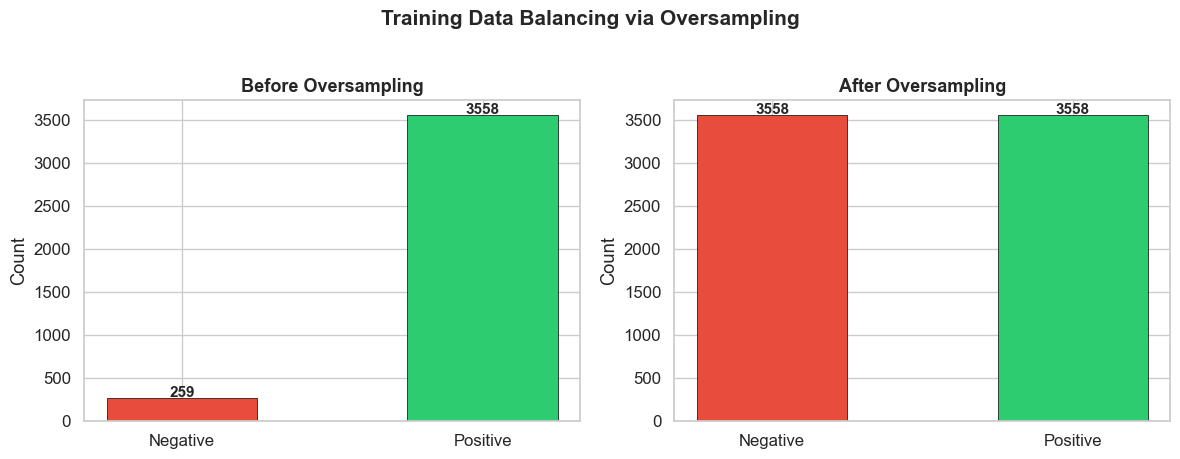

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

before = [n_neg, n_pos]
after = [sum(y_train_balanced==0), sum(y_train_balanced==1)]
labels = ['Negative', 'Positive']
bar_colors = ['#e74c3c', '#2ecc71']

for ax, vals, title in zip(axes, [before, after], ['Before Oversampling', 'After Oversampling']):
    bars = ax.bar(labels, vals, color=bar_colors, edgecolor='black', linewidth=0.5, width=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                str(v), ha='center', fontweight='bold', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Count')

plt.suptitle('Training Data Balancing via Oversampling', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../models/eda_oversampling.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🧠 5. Model Architecture

**Improved architecture:**
- Larger embedding dimension (128)
- `SpatialDropout1D` after embedding (regularizes word vectors)
- Stacked Bidirectional LSTM layers
- Batch normalization for training stability
- Learning rate scheduler for fine-tuning

In [28]:
model = Sequential([
    Embedding(VOCAB_SIZE, EMBEDDING_DIM, input_length=MAX_LEN),
    SpatialDropout1D(0.3),
    
    Bidirectional(LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.2)),
    Bidirectional(LSTM(64, return_sequences=False, dropout=0.2, recurrent_dropout=0.2)),
    
    BatchNormalization(),
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

optimizer = Adam(learning_rate=0.001)
model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

---
## 🏋️ 6. Model Training

In [29]:
EPOCHS = 15
BATCH_SIZE = 64

callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)
]

history = model.fit(
    X_train_balanced, y_train_balanced,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_seq, y_test),
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 342s 3s/step - accuracy: 0.8541 - loss: 0.3114 - val_accuracy: 0.9539 - val_loss: 0.2424 - learning_rate: 0.0010
Epoch 2/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 459s 4s/step - accuracy: 0.9830 - loss: 0.0586 - val_accuracy: 0.9508 - val_loss: 0.1479 - learning_rate: 0.0010
Epoch 3/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 457s 4s/step - accuracy: 0.9923 - loss: 0.0279 - val_accuracy: 0.9529 - val_loss: 0.2213 - learning_rate: 0.0010
Epoch 4/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9974 - loss: 0.0144
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
112/112 ━━━━━━━━━━━━━━━━━━━━ 446s 4s/step - accuracy: 0.9961 - loss: 0.0170 - val_accuracy: 0.9319 - val_loss: 0.3469 - learning_rate: 0.0010
Epoch 5/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 437s 4s/step - accuracy: 0.9976 - loss: 0.0112 - val_accuracy: 0.9592 - val_loss: 0.3525 - learning_rate: 5.0000e-04
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2

---
## 📊 7. Training History Charts

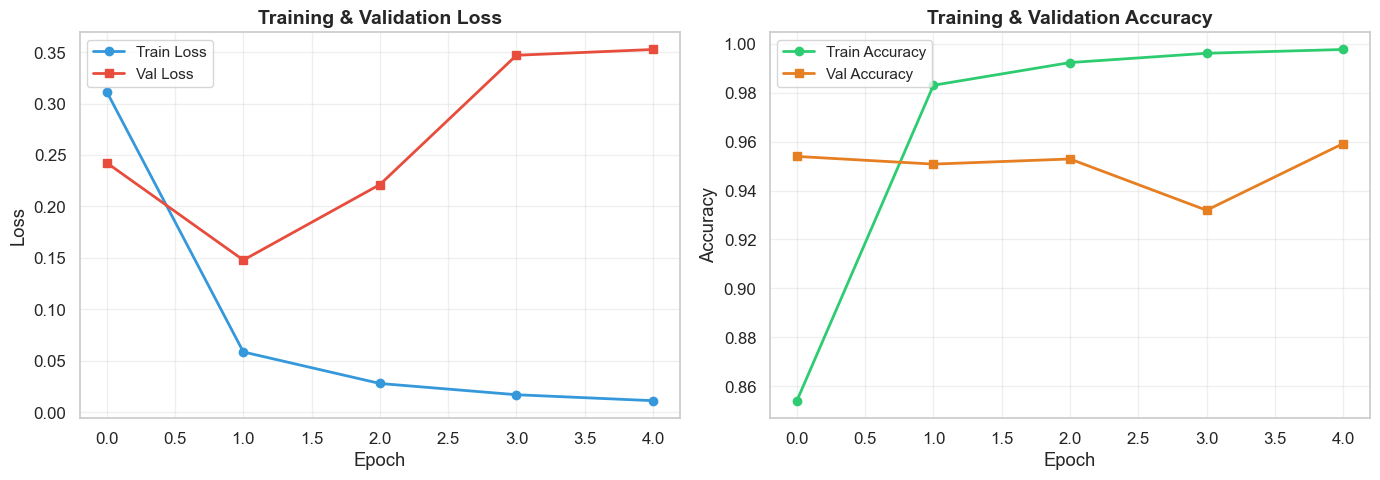

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], 'o-', label='Train Loss', color='#3498db', linewidth=2)
axes[0].plot(history.history['val_loss'], 's-', label='Val Loss', color='#e74c3c', linewidth=2)
axes[0].set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history.history['accuracy'], 'o-', label='Train Accuracy', color='#2ecc71', linewidth=2)
axes[1].plot(history.history['val_accuracy'], 's-', label='Val Accuracy', color='#e67e22', linewidth=2)
axes[1].set_title('Training & Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../models/training_history.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 📋 8. Model Evaluation

In [31]:
# Predict
y_pred_prob = model.predict(X_test_seq).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)

print('=' * 55)
print('           CLASSIFICATION REPORT')
print('=' * 55)
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 257ms/step
           CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Negative       0.62      0.69      0.66        65
    Positive       0.98      0.97      0.97       890

    accuracy                           0.95       955
   macro avg       0.80      0.83      0.82       955
weighted avg       0.95      0.95      0.95       955



### 📈 Evaluation Chart 1: Confusion Matrix

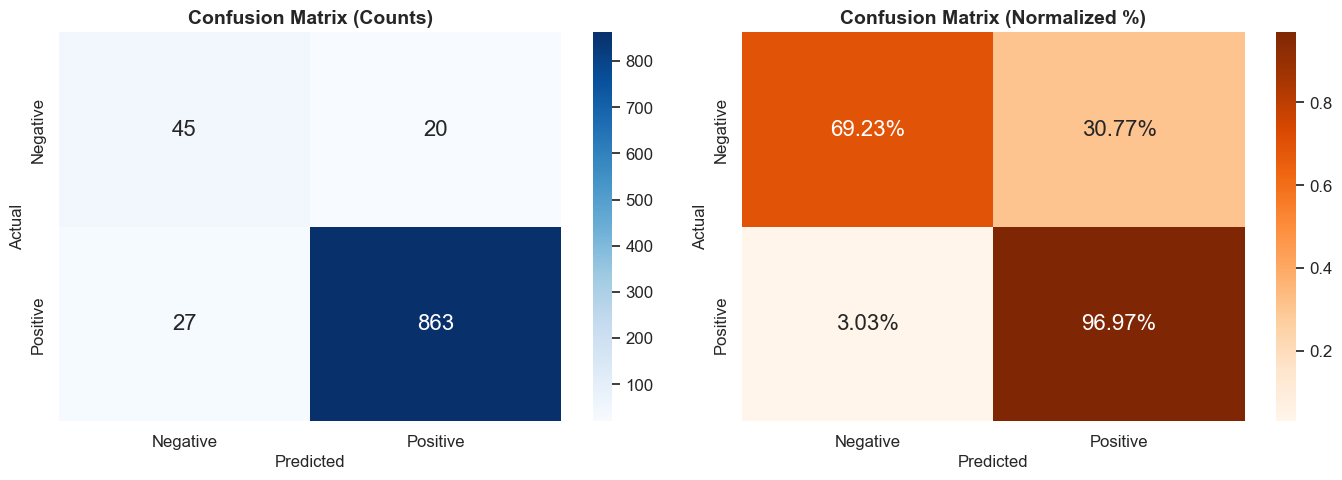

In [32]:
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'],
            annot_kws={'size': 16})
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')

# Normalized
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Oranges', ax=axes[1],
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'],
            annot_kws={'size': 16})
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('Actual', fontsize=12)
axes[1].set_title('Confusion Matrix (Normalized %)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../models/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### 📈 Evaluation Chart 2: ROC Curve

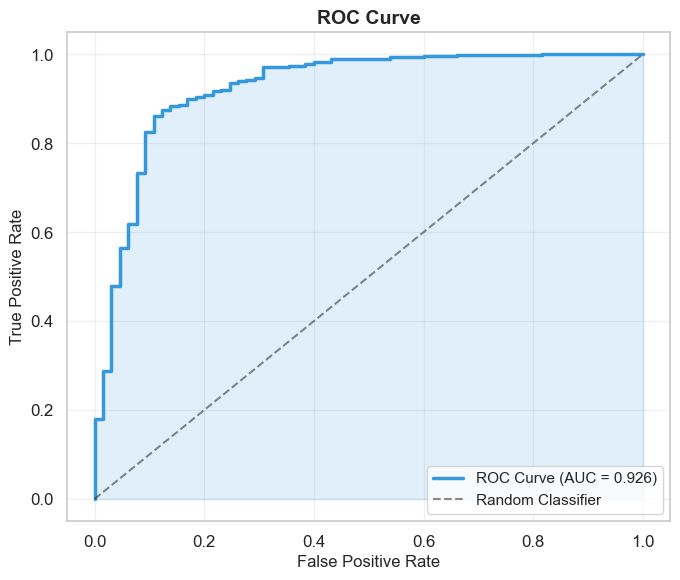

In [33]:
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='#3498db', linewidth=2.5, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.15, color='#3498db')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../models/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

### 📈 Evaluation Chart 3: Precision-Recall Curve

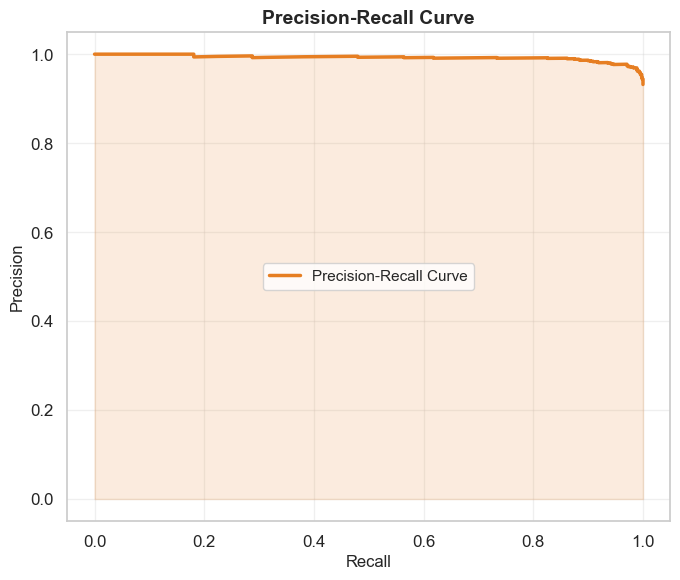

In [34]:
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_prob)

plt.figure(figsize=(7, 6))
plt.plot(recall_vals, precision_vals, color='#e67e22', linewidth=2.5, label='Precision-Recall Curve')
plt.fill_between(recall_vals, precision_vals, alpha=0.15, color='#e67e22')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../models/precision_recall_curve.png', dpi=150, bbox_inches='tight')
plt.show()

### 📈 Evaluation Chart 4: Per-Class Performance Comparison

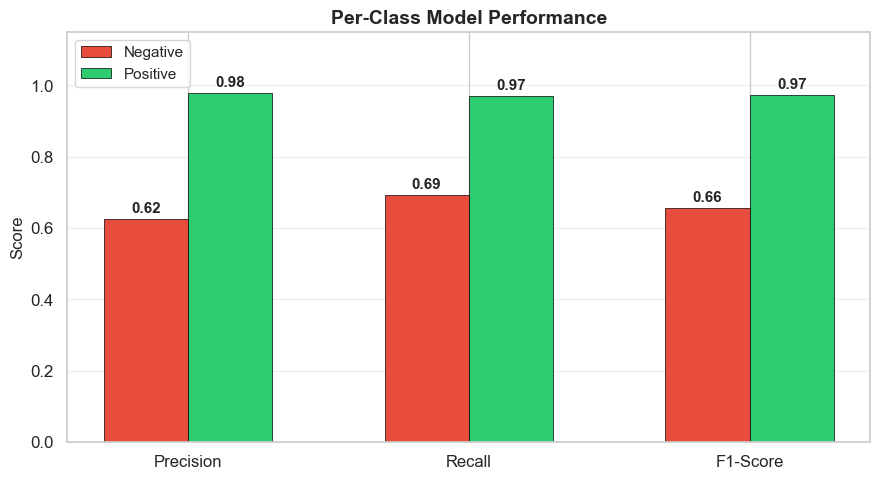

In [35]:
report = classification_report(y_test, y_pred, target_names=['Negative', 'Positive'], output_dict=True)

metrics = ['precision', 'recall', 'f1-score']
neg_scores = [report['Negative'][m] for m in metrics]
pos_scores = [report['Positive'][m] for m in metrics]

x = np.arange(len(metrics))
width = 0.3

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, neg_scores, width, label='Negative', color='#e74c3c', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x + width/2, pos_scores, width, label='Positive', color='#2ecc71', edgecolor='black', linewidth=0.5)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Per-Class Model Performance', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['Precision', 'Recall', 'F1-Score'], fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.15)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../models/per_class_performance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 💾 9. Save Best Model

In [36]:
# Save as .h5 (native Keras format)
model.save('../trained_models/best_sentiment_model.h5')
print('✅ Model saved as best_sentiment_model.h5')

# Save as .pkl (model config + weights — as requested)
model_data = {
    'config': model.get_config(),
    'weights': model.get_weights(),
    'vocab_size': VOCAB_SIZE,
    'max_length': MAX_LEN,
    'embedding_dim': EMBEDDING_DIM
}
with open('../trained_models/best_sentiment_model.pkl', 'wb') as f:
    pickle.dump(model_data, f)
print('✅ Model saved as best_sentiment_model.pkl')

print('\n📁 Files in trained_models:')
for fname in os.listdir('../trained_models'):
    fsize = os.path.getsize(f'../trained_models/{fname}') / (1024*1024)
    print(f'  {fname} ({fsize:.2f} MB)')

✅ Model saved as best_sentiment_model.h5
✅ Model saved as best_sentiment_model.pkl

📁 Files in trained_models:
  best_model.h5 (8.64 MB)
  best_model_weights.pkl (2.86 MB)
  best_sentiment_model.h5 (27.07 MB)
  best_sentiment_model.pkl (9.00 MB)
  tokenizer.pkl (0.32 MB)


---
## 🔮 10. Test Predictions on Sample Reviews

In [37]:
sample_reviews = [
    'This product is amazing! Best purchase I have ever made. Highly recommended!',
    'Terrible quality. Broke after one week. Complete waste of money.',
    'Works as expected, nothing special but does the job.',
    'Absolutely horrible experience. The item arrived damaged and customer service was unhelpful.',
    'Love it! Great value for money and super fast shipping.'
]

cleaned = [clean_text(r) for r in sample_reviews]
seq = pad_sequences(tokenizer.texts_to_sequences(cleaned), maxlen=MAX_LEN, padding='post', truncating='post')
preds = model.predict(seq).flatten()

print('\n' + '='*65)
print('  SAMPLE PREDICTIONS')
print('='*65)
for review, prob in zip(sample_reviews, preds):
    sentiment = '✅ POSITIVE' if prob > 0.5 else '❌ NEGATIVE'
    print(f'\n  Review: \"{review[:70]}...\"')
    print(f'  Prediction: {sentiment} (confidence: {max(prob, 1-prob)*100:.1f}%)')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step

  SAMPLE PREDICTIONS

  Review: "This product is amazing! Best purchase I have ever made. Highly recomm..."
  Prediction: ✅ POSITIVE (confidence: 99.7%)

  Review: "Terrible quality. Broke after one week. Complete waste of money...."
  Prediction: ❌ NEGATIVE (confidence: 91.2%)

  Review: "Works as expected, nothing special but does the job...."
  Prediction: ✅ POSITIVE (confidence: 97.5%)

  Review: "Absolutely horrible experience. The item arrived damaged and customer ..."
  Prediction: ✅ POSITIVE (confidence: 88.5%)

  Review: "Love it! Great value for money and super fast shipping...."
  Prediction: ✅ POSITIVE (confidence: 99.8%)
